# ACTIVIDAD 4 - ML
Clustering Dataset Sintético Circles

## Importación de librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, DBSCAN, SpectralClustering

from sklearn.metrics import (
    adjusted_rand_score,
    v_measure_score,
    silhouette_score,
    davies_bouldin_score
)

## Generación del dataset sintético Circle

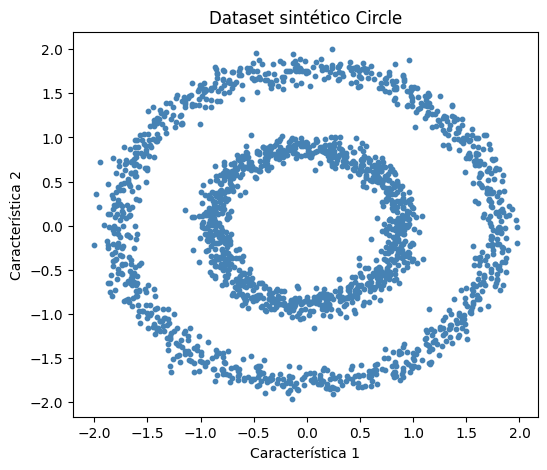

Tamaño del dataset: (2000, 2)
Clases reales: [0 1]


In [ ]:
X, y_true = make_circles(
    n_samples=2000,
    factor=0.5,
    noise=0.05,
    random_state=42
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], color="steelblue", s=10)
plt.title("Dataset sintético Circle")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()

print("Tamaño del dataset:", X_scaled.shape)
print("Clases reales:", np.unique(y_true))

## Aplicación del método del codo para K-means

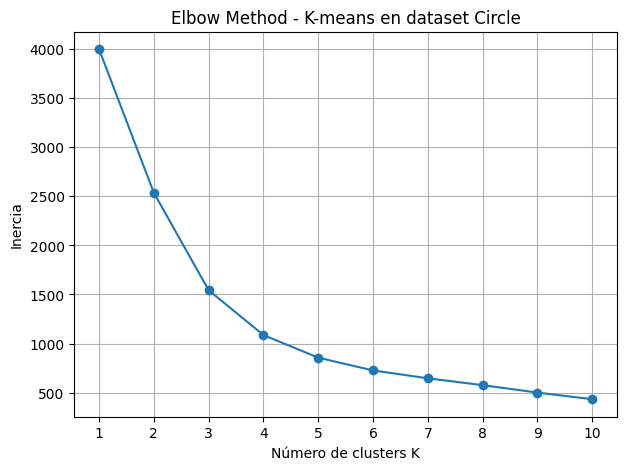

In [ ]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method - K-means en dataset Circle")
plt.xlabel("Número de clusters K")
plt.ylabel("Inercia")
plt.xticks(k_values)
plt.grid(True)
plt.show()

## Entrenamiento de los modelos de clustering

In [ ]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)
labels_kmeans = kmeans.fit_predict(X_scaled)


dbscan = DBSCAN(
    eps=0.15,
    min_samples=5
)
labels_dbscan = dbscan.fit_predict(X_scaled)


spectral = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=42
)
labels_spectral = spectral.fit_predict(X_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


## Visualización de los clusters obtenidos

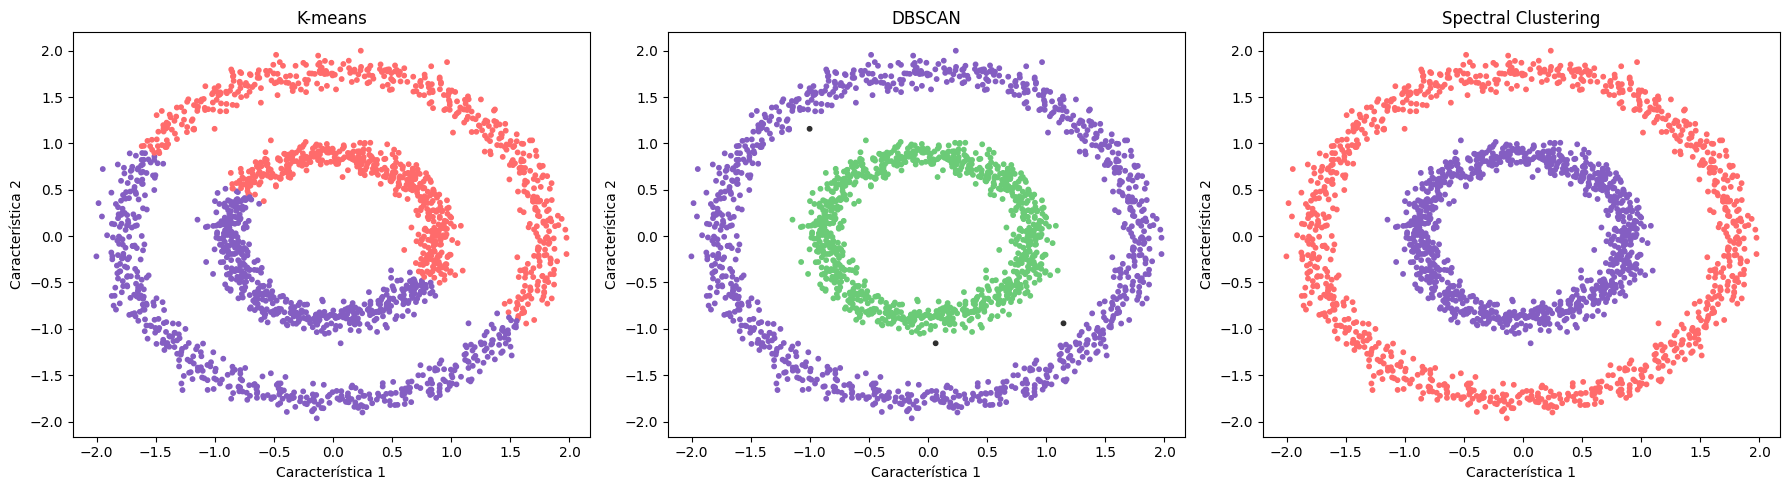

In [ ]:
from matplotlib.colors import ListedColormap

cmap_clusters = ListedColormap(["#FF6B6B", "#4D96FF", "#6BCB77", "#FFD93D", "#845EC2"])
cmap_dbscan = ListedColormap(["#2F2F2F", "#FF6B6B", "#4D96FF", "#6BCB77", "#FFD93D", "#845EC2"])

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_kmeans, cmap=cmap_clusters, s=10)
plt.title("K-means")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")

plt.subplot(1, 3, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_dbscan, cmap=cmap_dbscan, s=10)
plt.title("DBSCAN")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")

plt.subplot(1, 3, 3)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_spectral, cmap=cmap_clusters, s=10)
plt.title("Spectral Clustering")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")

plt.tight_layout()
plt.show()

## Evaluación de los modelos mediante métricas internas y externas

In [ ]:
def evaluar_modelo(nombre_modelo, X, y_true, labels):
    labels_unicos = set(labels)
    n_clusters = len(labels_unicos) - (1 if -1 in labels_unicos else 0)

    ari = adjusted_rand_score(y_true, labels)
    v_measure = v_measure_score(y_true, labels)

    if n_clusters >= 2:
        silhouette = silhouette_score(X, labels)
        davies_bouldin = davies_bouldin_score(X, labels)
    else:
        silhouette = np.nan
        davies_bouldin = np.nan

    return {
        "Modelo": nombre_modelo,
        "Clusters encontrados": n_clusters,
        "ARI": ari,
        "V-measure": v_measure,
        "Silhouette Score": silhouette,
        "Davies-Bouldin Index": davies_bouldin
    }

resultados = [
    evaluar_modelo("K-means", X_scaled, y_true, labels_kmeans),
    evaluar_modelo("DBSCAN", X_scaled, y_true, labels_dbscan),
    evaluar_modelo("Spectral Clustering", X_scaled, y_true, labels_spectral)
]

df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,Clusters encontrados,ARI,V-measure,Silhouette Score,Davies-Bouldin Index
0,K-means,2,-0.000451,0.000035,0.354484,1.183099
1,DBSCAN,2,0.997001,0.991320,0.027898,722.752610
2,Spectral Clustering,2,1.000000,1.000000,0.114964,780.299977
